In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv("bodyPerformance.csv")

In [3]:
# Cambiamos a enteros los datos de género
df['gender'] = df['gender'].map({'M': 1, 'F': 0})

df['bmi'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)
df['relative_grip'] = df['gripForce'] / df['weight_kg']

In [4]:
# Dividimos entre datos y objetivo teniendo en cuenta el género
X = df[df['gender'] == 1].drop('class', axis=1)
y = df[df['gender'] == 1]['class']

In [5]:
#Separamos entre train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [7]:
# Modelamos el Random Forest con Grid Search
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 216 candidates, totalling 648 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

In [8]:
best_model = grid_search.best_estimator_
print("Mejor precisión del Random Forest: ", best_model.score(X_test, y_test))

Mejor precisión del Random Forest:  0.743801652892562


In [9]:
y_pred = grid_search.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del Random Forest en Test: {accuracy:.4f}")

Accuracy del Random Forest en Test: 0.7438


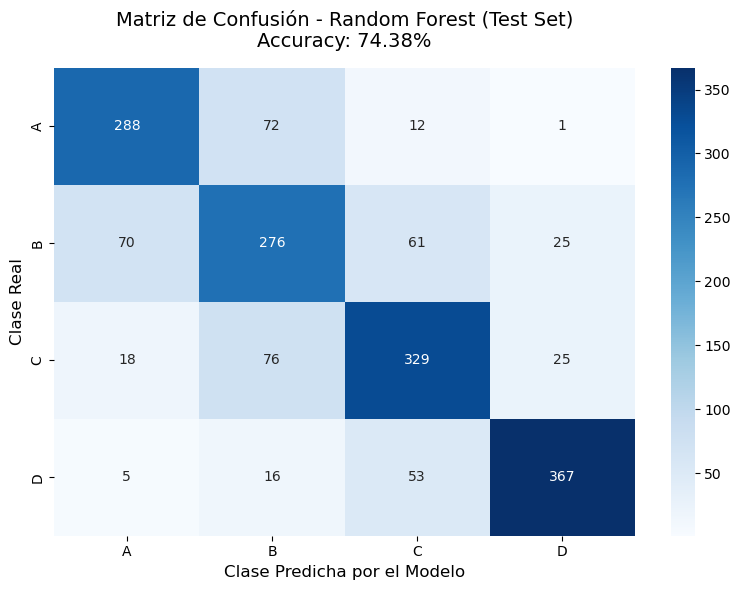

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=['A', 'B', 'C', 'D'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['A', 'B', 'C', 'D'], 
            yticklabels=['A', 'B', 'C', 'D'])
plt.title(f'Matriz de Confusión - Random Forest (Test Set)\nAccuracy: {accuracy:.2%}', fontsize=14, pad=15)
plt.xlabel('Clase Predicha por el Modelo', fontsize=12)
plt.ylabel('Clase Real', fontsize=12)
plt.tight_layout()

# plt.savefig('matriz_confusion_rf.png')
plt.show()

C:\Users\miguelmr\AppData\Local\Temp\ipykernel_11196\3237121563.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importance_df, palette='viridis')


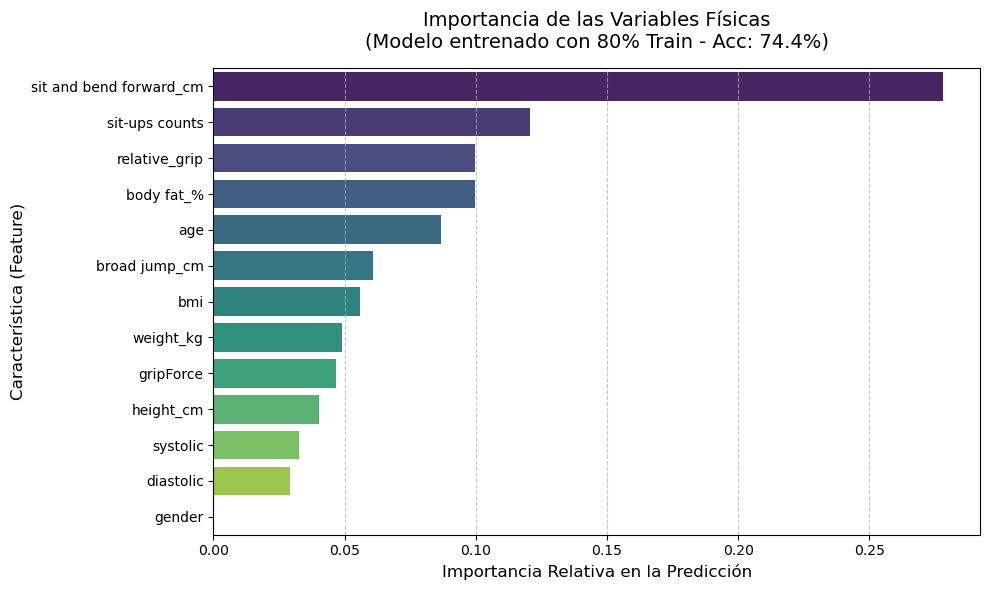

In [11]:
importance_df = pd.DataFrame({
    'Variable': X_train.columns, 
    'Importancia': best_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Crear la gráfica de Importancia
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importance_df, palette='viridis')

plt.title(f'Importancia de las Variables Físicas\n(Modelo entrenado con 80% Train - Acc: {accuracy:.1%})', fontsize=14, pad=15)
plt.xlabel('Importancia Relativa en la Predicción', fontsize=12)
plt.ylabel('Característica (Feature)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Guardar la gráfica
# plt.savefig('importancia_variables_split.png')
plt.show()